## Imports

In [1]:
%matplotlib inline
import numpy as np
from numpy import random
import random
import math
import matplotlib.pyplot as plt
from operator import add
import itertools
import seaborn as sns
import nest


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:22

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
import os
import sys, site
print(sys.executable)
print(sys.version)
print(site.getsitepackages())
Path = os.getcwd()
sys.path.append(Path)
from utilities1 import *
from build_network import *
from build_simulation import *

/home/tonje/master/TIS/venv/bin/python
3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
['/home/tonje/master/TIS/venv/lib/python3.12/site-packages', '/home/tonje/master/TIS/venv/local/lib/python3.12/dist-packages', '/home/tonje/master/TIS/venv/lib/python3/dist-packages', '/home/tonje/master/TIS/venv/lib/python3.12/dist-packages']


In [3]:
def color_plot(a_values, SD_values, second_sine=False, f=10, sim_time=100e3, beat=20, fontsize=16, save_fig=False):
    """"This function plots 2d colorplots showing the firing rate and power 
    as a function of the strength of the AC current (tES) and the noisy current"""
    ymax_fft = 0
    array = np.zeros((len(a_values),len(SD_values)))
    array_fft = np.zeros((len(a_values),len(SD_values)))
    
    for i, a in enumerate(a_values):
        for j, sd in enumerate(SD_values):
            
            results = build_simulation(sim_time=sim_time, noisy=True, f1=f, a=a, SD=sd, resolution=0.25,
                                      second_sine=second_sine, beat=beat)
            
            
            
            spike_times = results["spike_times"]
            spikes = len(spike_times)
            array[i,j] = 1000*spikes/sim_time
            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=0.25)
            idx_f = np.argmin(np.abs(freqs - f))  #finner nærmeste indeks til f
            if second_sine:
                idx_f = np.argmin(np.abs(freqs - beat))
            
            if len(spike_times) > 0:
                array_fft[i, j] = np.abs(psd_values[idx_f])#np.abs(fft_values[idx_f])/len(spike_times)
            else:
                array_fft[i, j] = 0
       
    fig, ax = plt.subplots(ncols=2, figsize=(20,8))        
    im = ax[0].imshow(array, cmap="PuBuGn_r", vmin=np.min(array), vmax=np.max(array),
                      aspect="auto", origin="lower")

    for i in range(len(a_values)):
        for j in range(len(SD_values)):

            star = "*" if SD_values[j] == 250 and a_values[i] == 1000 else ""
            color = "red" if SD_values[j] == 250 and a_values[i] == 1000 else "black"
    
            ax[0].text(
                j, i,
                f"{array[i, j]:.0f}{star}",
                ha="center",
                va="center",
                fontsize=8,
                color=color
            )
    
            ax[1].text(
                j, i,
                f"{array_fft[i, j]:.0f}{star}",
                ha="center",
                va="center",
                fontsize=8,
                color=color
            )
                    
    ax[0].set_xticks(np.arange(len(SD_values)))  
    ax[0].set_xticklabels([f"{sd:.0f}" for sd in SD_values], rotation=45) 
    ax[0].set_yticks(np.arange(len(a_values)))
    ax[0].set_yticklabels([f"{a:.0f}" for a in a_values])  
    ax[0].set_xlabel(r"$\sigma_I$ [pA]", color="#006D5B", fontsize=16)
    ax[0].set_ylabel(r"$I_{\mathrm{I}}$ [pA]", color="#006D5B", fontsize=16)
    ax[0].set_title("A. Firing rate vs. $I_{\mathrm{I}}$ and $\sigma_I$", fontsize=fontsize, color="#006D5B", fontweight='bold')
    ax[0].tick_params(axis='x', labelsize=16)
    ax[0].tick_params(axis='y', labelsize=16)
    cbar = fig.colorbar(im, ax=ax[0])
    cbar.set_label("[Spikes/sec]", color="#006D5B", fontsize=16)  
    cbar.ax.yaxis.set_tick_params(color="#006D5B", labelsize=16) 
    print("Min log10:", np.min(np.log10(array_fft + 1e-12)))
    print("Max log10:", np.max(np.log10(array_fft + 1e-12)))
          
    imf = ax[1].imshow(array_fft, cmap="PuBuGn_r", vmin=np.min(array_fft), vmax=np.max(array_fft),
                       aspect="auto", origin="lower")
    ax[1].set_xticks(np.arange(len(SD_values)))  
    ax[1].set_xticklabels([f"{sd:.0f}" for sd in SD_values], rotation=45)  
    ax[1].set_yticks(np.arange(len(a_values)))
    ax[1].set_yticklabels([f"{a:.0f}" for a in a_values])  
    ax[1].set_xlabel("$I_\mathrm{\sigma}$ [pA]", color="#006D5B", fontsize=16)
    ax[1].set_ylabel("$I_{\mathrm{I}}$ [pA]", color="#006D5B", fontsize=16)
    ax[1].set_title("B. Power at $f=20\,\mathrm{Hz}$ vs. $I_{\mathrm{I}}$ and $I_\mathrm{\sigma}$", fontsize=fontsize, color="#006D5B", fontweight='bold') 
    ax[1].tick_params(axis='x', labelsize=16)
    ax[1].tick_params(axis='y', labelsize=16)
    cbar = fig.colorbar(imf, ax=ax[1])
    cbar.set_label(r"[$\mathrm{spikes}^2/\mathrm{Hz}$]", color="#006D5B", fontsize=16)
    cbar.ax.yaxis.set_tick_params(color="#006D5B", labelsize=16) 
    plt.tight_layout()
    if save_fig:
        save_figure(plt.gcf(), "heatmaps")
    
    plt.show()
            

<>:63: SyntaxWarning:invalid escape sequence '\m'
<>:78: SyntaxWarning:invalid escape sequence '\m'
<>:79: SyntaxWarning:invalid escape sequence '\m'
<>:80: SyntaxWarning:invalid escape sequence '\,'
<>:63: SyntaxWarning:invalid escape sequence '\m'
<>:78: SyntaxWarning:invalid escape sequence '\m'
<>:79: SyntaxWarning:invalid escape sequence '\m'
<>:80: SyntaxWarning:invalid escape sequence '\,'
/tmp/ipykernel_538246/3186825165.py:63: SyntaxWarning:invalid escape sequence '\m'
/tmp/ipykernel_538246/3186825165.py:78: SyntaxWarning:invalid escape sequence '\m'
/tmp/ipykernel_538246/3186825165.py:79: SyntaxWarning:invalid escape sequence '\m'
/tmp/ipykernel_538246/3186825165.py:80: SyntaxWarning:invalid escape sequence '\,'



Apr 30 19:51:07 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 30 19:51:07 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
Min log10: -12.0
Max log10: 3.1046576733432185
Saved plot as: /home/tonje/master/TIS/results/heatmaps_22.png


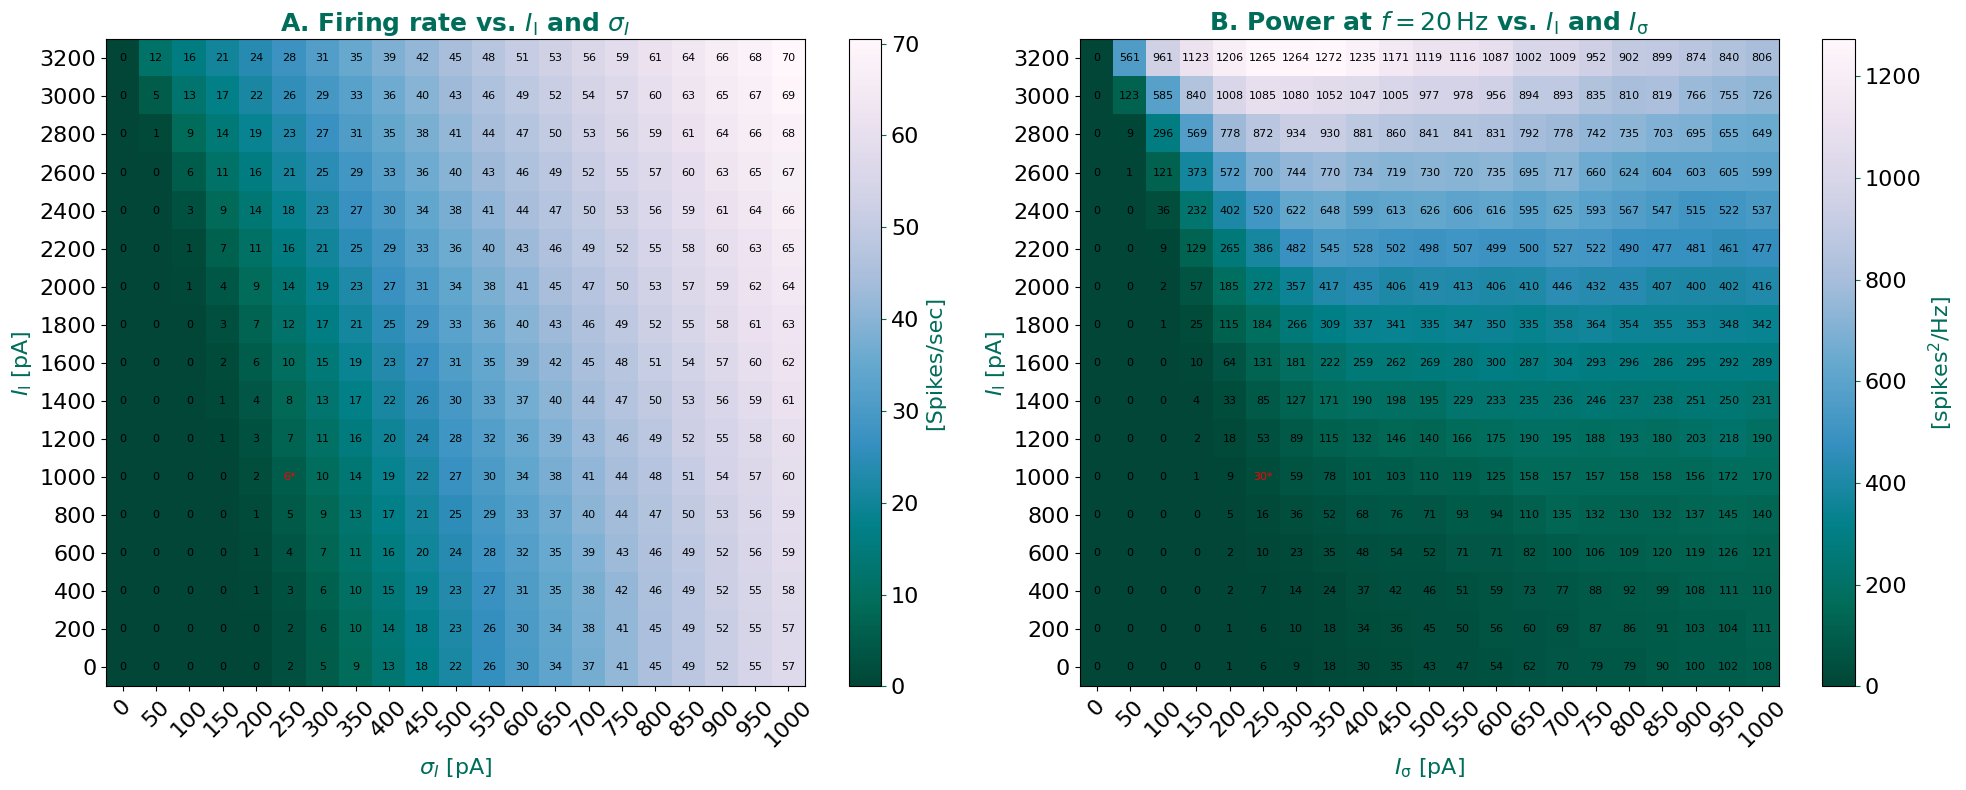

In [6]:
color_plot(a_values=np.linspace(0,3200,17), SD_values=np.linspace(0,1000,21), sim_time=100e3, f=1000, second_sine=True, beat=20,
           fontsize=18, save_fig=True)

In [ ]:
"""Parsevals theorem"""
def heatmap_psd_sum(a_values, SD_values, second_sine=False, f=10, sim_time=10e3, beat=20, fontsize=16, save_fig=False):
    ymax_fft = 0
    array = np.zeros((len(a_values),len(SD_values)))
    array_fft = np.zeros((len(a_values),len(SD_values)))
    
    plt.rcParams["font.family"] = "Dejavu Serif"
    
    for i, a in enumerate(a_values):
        for j, sd in enumerate(SD_values):
            
            results = build_simulation(sim_time=sim_time, noisy=True, f1=f, a=a, SD=sd, resolution=0.5,
                                      second_sine=second_sine, beat=beat)
            
            spike_times = results["spike_times"]
            spikes = len(spike_times)
            array[i,j] = 1000*spikes/sim_time
            freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=0.25)
            idx_f = np.argmin(np.abs(freqs - f))  #finner nærmeste indeks til f
            
            
            if len(spike_times) > 0:
                array_fft[i, j] = np.sum(psd_values)#np.abs(fft_values[idx_f])/len(spike_times)
            else:
                array_fft[i, j] = 0
            
            diff_psd_fr = array[i,j]-array[i,j]
           
            if diff_psd_fr != 0:
                print("value not identical. Diff:", diff_psd_fr)
    fig, ax = plt.subplots(ncols=2, figsize=(20,8))        
    im = ax[0].imshow(array, cmap="PuBuGn_r", vmin=np.min(array), vmax=np.max(array),
                      aspect="auto", origin="lower")
    ax[0].set_xticks(np.arange(len(SD_values)))  
    ax[0].set_xticklabels([f"{sd:.0f}" for sd in SD_values], rotation=45) 
    ax[0].set_yticks(np.arange(len(a_values)))
    ax[0].set_yticklabels([f"{a:.0f}" for a in a_values])  
    ax[0].set_xlabel(r"$\sigma_I$ [pA]", color="#006D5B", fontsize=18)
    ax[0].set_ylabel(r"$I_{\mathrm{I}}$ [pA]", color="#006D5B", fontsize=18)
    ax[0].set_title("A. Firing rate vs. $I_{\mathrm{I}}$ and $I_\mathrm{sigma}$", fontsize=20, color="#006D5B", fontweight='bold')
    ax[0].tick_params(axis='x', labelsize=14)
    ax[0].tick_params(axis='y', labelsize=14)
    cbar = fig.colorbar(im, ax=ax[0])
    cbar.set_label("Spikes per second", color="#006D5B", fontsize=18)  
    cbar.ax.yaxis.set_tick_params(color="#006D5B", labelsize=16) 
    print("Min log10:", np.min(np.log10(array_fft + 1e-12)))
    print("Max log10:", np.max(np.log10(array_fft + 1e-12)))
          
    imf = ax[1].imshow(array_fft, cmap="PuBuGn_r", vmin=np.min(array_fft), vmax=np.max(array_fft),
                       aspect="auto", origin="lower")
    ax[1].set_xticks(np.arange(len(SD_values)))  
    ax[1].set_xticklabels([f"{sd:.0f}" for sd in SD_values], rotation=45)  
    ax[1].set_yticks(np.arange(len(a_values)))
    ax[1].set_yticklabels([f"{a:.0f}" for a in a_values])  
    ax[1].set_xlabel("$\sigma_I$ [pA]", color="#006D5B", fontsize=18)
    ax[1].set_ylabel("$I_{\mathrm{I}}$ [pA]", color="#006D5B", fontsize=18)
    ax[1].set_title("B. Power at $f = 20$ Hz vs. $I_{\mathrm{I}}$ and $I_\mathrm{sigma}$", fontsize=fontsize, color="#006D5B", fontweight='bold') 
    ax[1].tick_params(axis='x', labelsize=14)
    ax[1].tick_params(axis='y', labelsize=14)
    cbar = fig.colorbar(imf, ax=ax[1])
    cbar.set_label("PSD", color="#006D5B", fontsize=18) 
    cbar.ax.yaxis.set_tick_params(color="#006D5B", labelsize=16) 
    plt.tight_layout()
    if save_fig:
        save_figure(plt.gcf(), "heatmaps")
    
    plt.show()
            
        

<>:40: SyntaxWarning:invalid escape sequence '\m'
<>:55: SyntaxWarning:invalid escape sequence '\s'
<>:56: SyntaxWarning:invalid escape sequence '\m'
<>:57: SyntaxWarning:invalid escape sequence '\m'
<>:40: SyntaxWarning:invalid escape sequence '\m'
<>:55: SyntaxWarning:invalid escape sequence '\s'
<>:56: SyntaxWarning:invalid escape sequence '\m'
<>:57: SyntaxWarning:invalid escape sequence '\m'
/tmp/ipykernel_307843/2908879852.py:40: SyntaxWarning:invalid escape sequence '\m'
/tmp/ipykernel_307843/2908879852.py:55: SyntaxWarning:invalid escape sequence '\s'
/tmp/ipykernel_307843/2908879852.py:56: SyntaxWarning:invalid escape sequence '\m'
/tmp/ipykernel_307843/2908879852.py:57: SyntaxWarning:invalid escape sequence '\m'


Min log10: -12.0
Max log10: 5.317928837029519
Saved plot as: /home/tonje/master/TIS/results/heatmaps_4.png


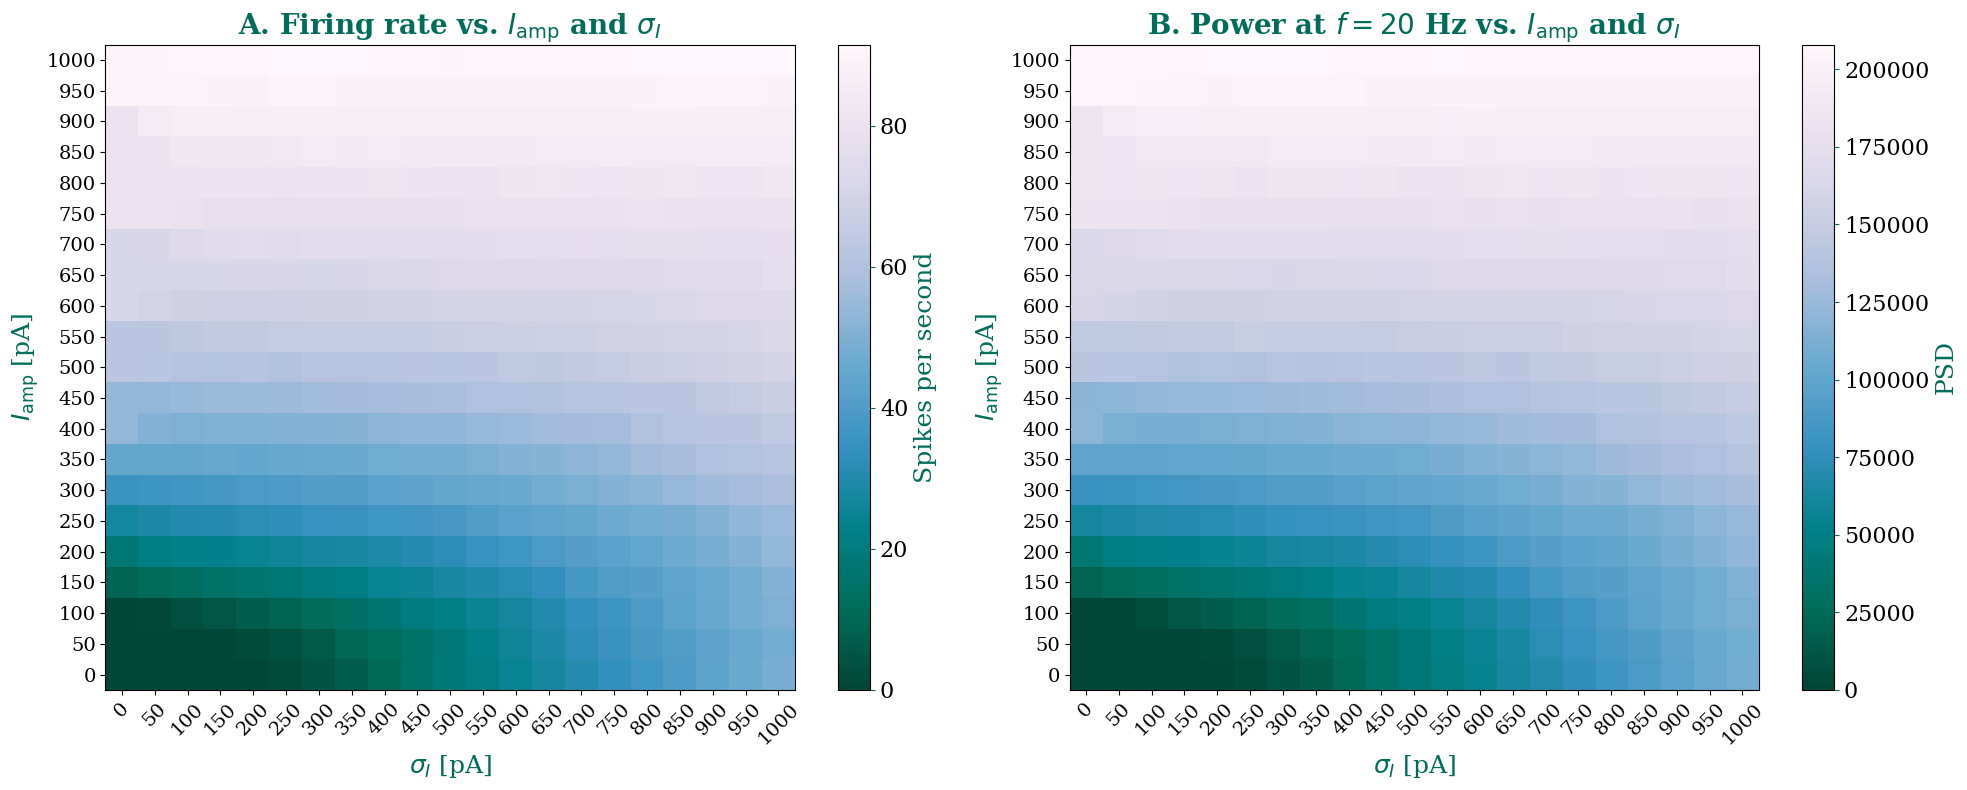

In [14]:
heatmap_psd_sum(a_values=np.linspace(0,1000,21), SD_values=np.linspace(0,1000,21), sim_time=10e3, f=10, second_sine=False, beat=20,
           fontsize=20, save_fig=True)

Min log10: -12.0
Max log10: 6.183018019453287
Saved plot as: /home/tonje/master/TIS/results/heatmaps_5.png


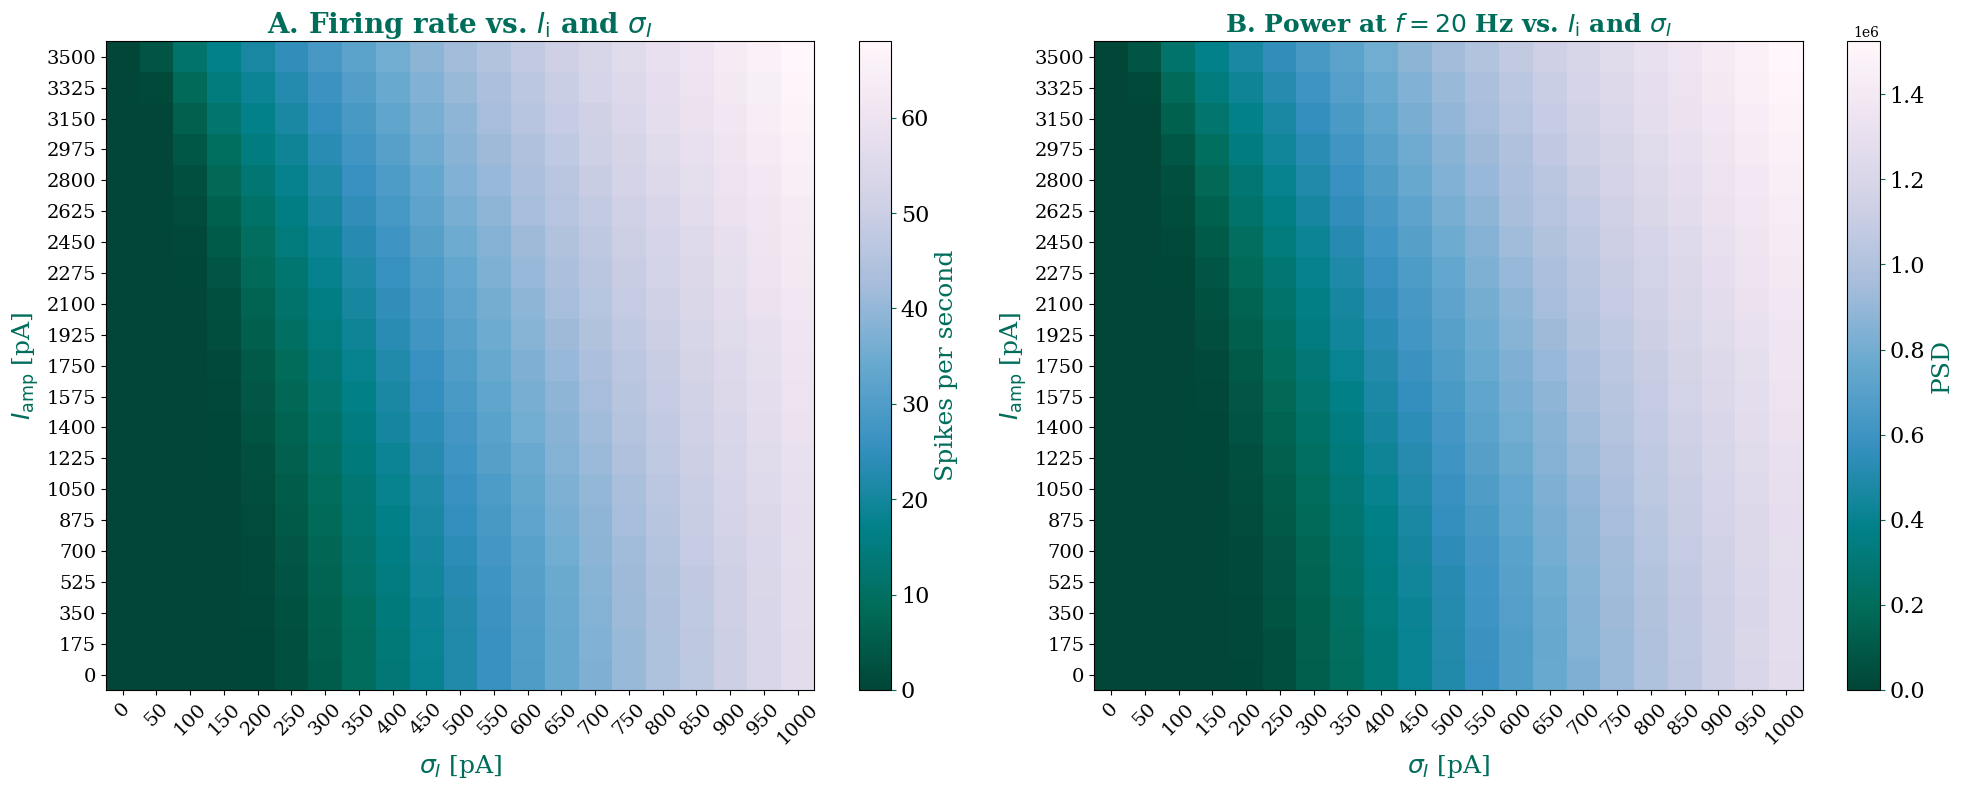

In [16]:
# fig 5
heatmap_psd_sum(a_values=np.linspace(0,3500,21), SD_values=np.linspace(0,1000,21), sim_time=100e3, f=1000, second_sine=True, beat=20,
           fontsize=18, save_fig=True)

In [4]:
# fig 8 - SNR vs input amplitude (current strength) and noise level
import time 

def snr_vs_amp_and_noise(a_values, noise_values, window=5,  sim_time=100e3, save_fig=False, f=1000, num_A=1000, measure_from_A=False):
    start = time.time()
    plt.rcParams["font.family"] = "DejaVu Serif"
    
    print(f"simulation time: {sim_time}")
    beat = 20
    resolution = 0.25
    bin_size = 0.25
    beat = 20
    
    x_labels = [f"{N_A:.0f}" for N_A in noise_values]
    array_snr = np.zeros((len(a_values), len(noise_values)))
    
    for i, a in enumerate(a_values):
        for j, sd in enumerate(noise_values):
            results = build_network(sim_time=sim_time, num_A=num_A, weight=1,
                                    noisy=True, second_sine=True, beat=beat,
                                    f1=f, a=a, SD=sd,
                                    resolution=resolution, measure_from_A=measure_from_A)
    
            spike_times = results["spike_times"]

            
            if len(spike_times) > 0:
                freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size, segments=16)
                psd_values = np.abs(psd_values)
                if len(freqs) == 0 or len(psd_values) == 0:
                    print(f"[ADVARSEL] Tom PSD for a={a}, N={N_A}")
                    array_snr[i, j] = 0
                    continue
                    
                arg_f_beat = np.argmin(np.abs(freqs - beat))
                signal = psd_values[arg_f_beat]
                noise_mask = (freqs >= freqs[arg_f_beat] - window) & (freqs <= freqs[arg_f_beat] + window)
                noise = np.mean(psd_values[noise_mask])
    
                snr = signal / noise if noise > 0 else 0
                array_snr[i, j] = snr
            else:
                array_snr[i, j] = 0
        print(a)
        print("spikerate:", spike_times/len(spike_times))
    
    # --- Plot heatmap ---
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(array_snr, cmap="PuBuGn_r", origin="lower", aspect="auto")
    for i in range(len(a_values)):
        for j in range(len(noise_values)):

            star = "*" if noise_values[j] == 250 and a_values[i] == 1000 else ""
            color = "red" if noise_values[j] == 250 and a_values[i] == 1000 else "black"
            ax.text(
                j, i,
                f"{array_snr[i, j]:.0f}{star}",
                ha="center",
                va="center",
                fontsize=8,
                color=color
            )


               
         
    
    
    ax.set_xticks(np.arange(len(noise_values)))
    ax.set_xticklabels([f"{N:.0f}" for N in noise_values], rotation=45)
    ax.set_yticks(np.arange(len(a_values)))
    ax.set_yticklabels([f"{a:.0f}" for a in a_values])
    ax.tick_params(axis='both', labelsize=16)
    ax.set_xlabel(r"$I_\mathrm{\sigma}$ [pA]", fontsize=16, color="#006D5B")
    #ax.set_xlabel(r"$N_A \cdot w$ [pA]", fontsize=14, color="#006D5B")
    ax.set_ylabel(r"$I_{\mathrm{I}}$ [pA]", fontsize=16, color="#006D5B")
    ax.set_title(r"C. SNR[f=1000] vs. $I_\mathrm{I}$ and $I_\mathrm{\sigma}$ ", fontsize=20, color="#006D5B", fontweight='bold')
    
    cbar = fig.colorbar(im)
    cbar.set_label("SNR", color="#006D5B", fontsize=16)
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout()
    if save_fig:
        plt.savefig("snr_heatmap_1000.png", dpi=300)
    
    plt.show()
    
    end = time.time()
    print("Time elapsed:", end - start)
    

In [ ]:
# resolution?? noise level interval?? 
snr_vs_amp_and_noise(a_values=np.linspace(0,3500,21), noise_values=np.linspace(0,1000,21), window=5,  sim_time=100e3, save_fig=False, f=1000, num_A=1000)

simulation time: 100000.0


## SNR plot - presyn populasjon

simulation time: 100000.0

Apr 30 19:57:08 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 30 19:57:08 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.

Apr 30 19:57:09 SimulationManager::run [Warning]: 
    The requested simulation time is not an integer multiple of the minimal 
    delay in the network. This may result in inconsistent results under the 
    following conditions: (i) A network contains more than one source of 
    randomness, e.g., two different poisson_generators, and (ii) Simulate is 
    called repeatedly with simulation times that are not multiples of the 
    minimal delay.

Apr 30 19:57:10 SimulationManager::run [Warning]: 
    The requested simulation time is not an integer multiple of the minimal 
    delay in the network. This may result in inconsistent results under the 
    following conditions: (i) A network contains more than one source of 
    randomness, e.g., two 

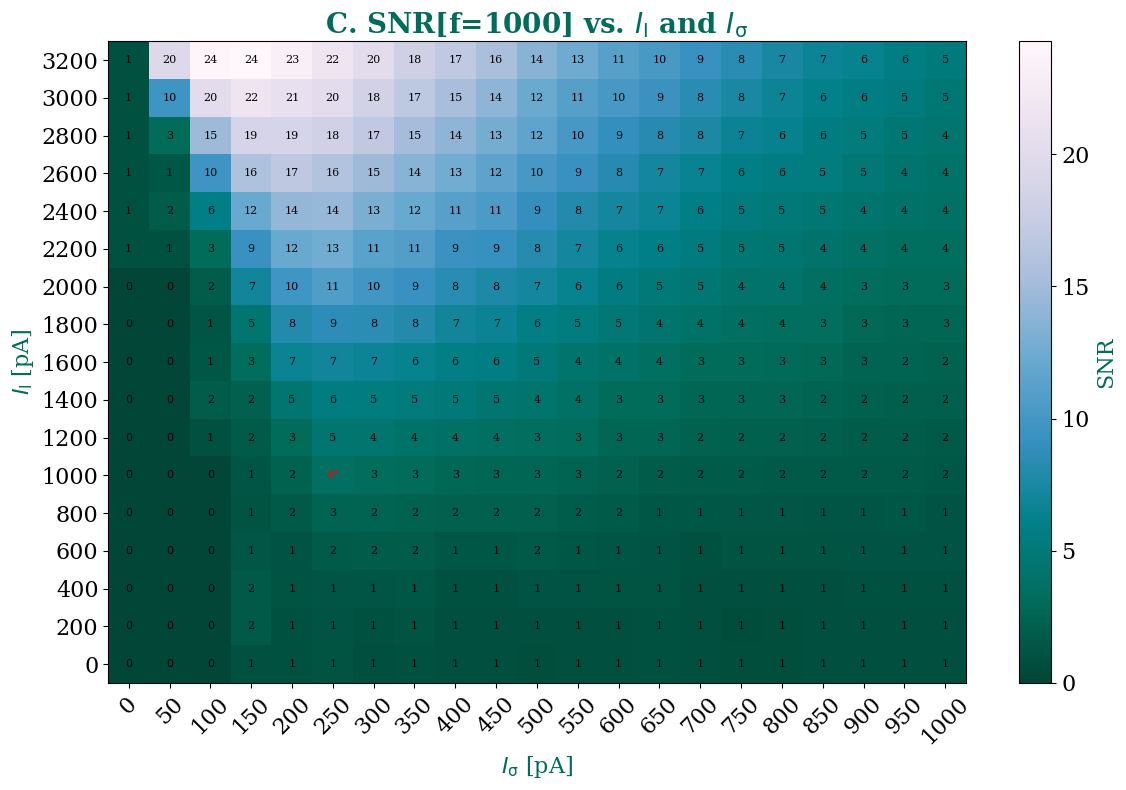

Time elapsed: 1179.780942440033


In [5]:
# population A - fig 5 C 
snr_vs_amp_and_noise(a_values=np.linspace(0,3200,17), noise_values=np.linspace(0,1000,21), window=5,  sim_time=100e3, save_fig=False, f=1000, num_A=2, measure_from_A=True)

simulation time: 100000.0

Apr 15 09:45:32 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 15 09:45:32 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
0.0
spikerate: [3.56257745e-04 6.97026022e-04 1.03779430e-03 ... 6.19518278e+00
 6.19552354e+00 6.19569393e+00]
350.0
spikerate: [3.55486862e-04 6.95517774e-04 1.03554869e-03 ... 6.18177743e+00
 6.18211747e+00 6.18228748e+00]
700.0
spikerate: [3.37423313e-04 6.74846626e-04 1.02760736e-03 ... 6.13437117e+00
 6.13470859e+00 6.13487730e+00]
1050.0
spikerate: [3.17912075e-04 6.20685479e-04 1.01429090e-03 ... 6.05487768e+00
 6.05521073e+00 6.05537726e+00]
1400.0
spikerate: [3.13283208e-04 5.51975176e-04 9.99522616e-04 ... 5.96670247e+00
 5.96703067e+00 5.96719477e+00]
1750.0
spikerate: [3.08406274e-04 5.28696469e-04 8.66474769e-04 ... 5.87371497e+00
 5.87406744e+00 5.87422898e+00]
2100.0
spikerate: [2.88317380e-04 5.04555415e-04 8.50536270e-04 ... 5.765

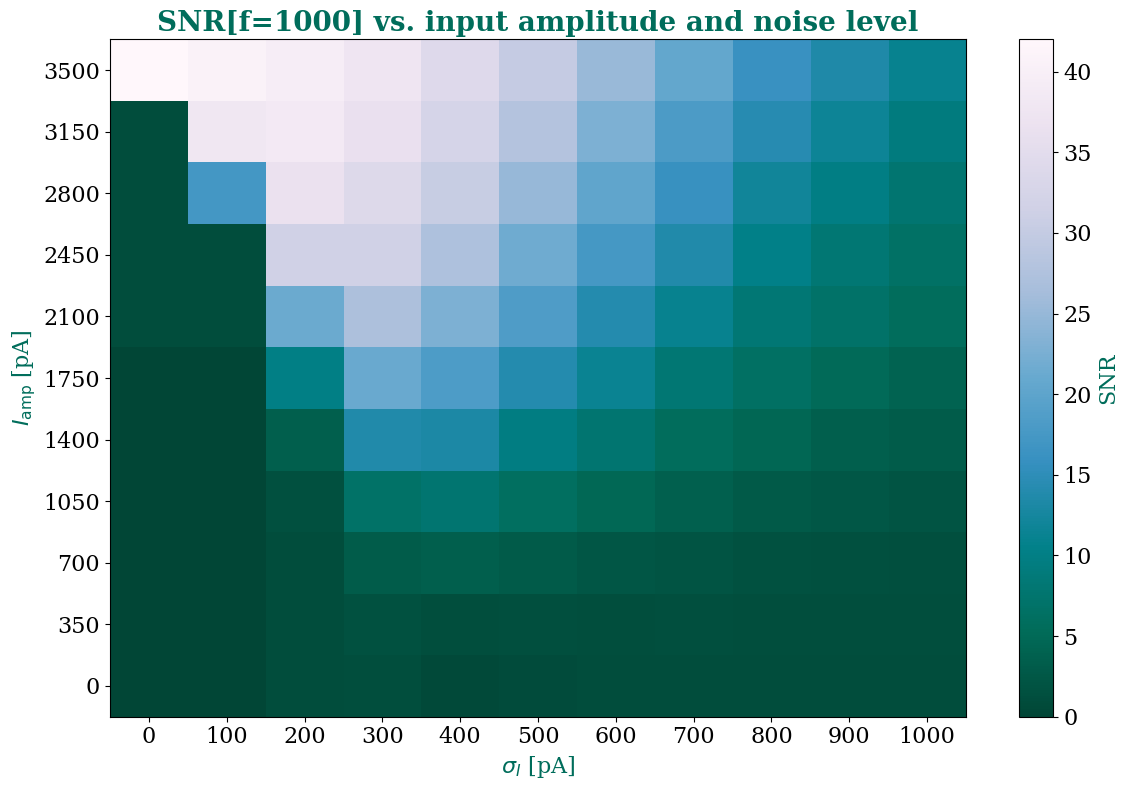

Time elapsed: 9213.415008068085


In [ ]:

snr_vs_amp_and_noise(a_values=np.linspace(0,3500,11), noise_values=np.linspace(0,1000,11), window=5,  sim_time=100e3, save_fig=False, f=1000, num_A=1000)

In [ ]:
import time

def snr_heatmap(a_values, num_A_values, window=5,  sim_time=100e3, save_fig=False, f=1000):
    start = time.time()
    plt.rcParams["font.family"] = "DejaVu Serif"
    
    print(f"simulation time: {sim_time}")
    beat = 20
    resolution = 0.25
    bin_size = 0.25

    
    x_labels = [f"{N_A:.0f}" for N_A in num_A_values]
    array_snr = np.zeros((len(a_values), len(num_A_values)))
    
    for i, a in enumerate(a_values):
        for j, N_A in enumerate(num_A_values):
            results = build_network(sim_time=sim_time, num_A=N_A, weight=1,
                                    noisy=True, second_sine=True, beat=beat,
                                    f1=f, a=a, SD=250,
                                    resolution=resolution)
    
            spike_times = results["spike_times"]
            
            if len(spike_times) > 0:
                freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size, segments=16)
                psd_values = np.abs(psd_values)
                if len(freqs) == 0 or len(psd_values) == 0:
                    print(f"[ADVARSEL] Tom PSD for a={a}, N={N_A}")
                    array_snr[i, j] = 0
                    continue
                    
                arg_f_beat = np.argmin(np.abs(freqs - beat))
                signal = psd_values[arg_f_beat]
                noise_mask = (freqs >= freqs[arg_f_beat] - window) & (freqs <= freqs[arg_f_beat] + window)
                noise = np.mean(psd_values[noise_mask])
    
                snr = signal / noise if noise > 0 else 0
                array_snr[i, j] = snr
            else:
                array_snr[i, j] = 0
        print(a)
        print("spikerate:", spike_times/len(spike_times))
    
    # --- Plot heatmap ---
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(array_snr, cmap="PuBuGn_r", origin="lower", aspect="auto")

    
    
    ax.set_xticks(np.arange(len(num_A_values)))
    ax.set_xticklabels([f"{N:.0f}" for N in num_A_values]m rotation=45)
    ax.set_yticks(np.arange(len(a_values)))
    ax.set_yticklabels([f"{a:.0f}" for a in a_values])
    ax.tick_params(axis='both', labelsize=16)
    ax.set_xlabel(r"$N_A$", fontsize=16, color="#006D5B")
    #ax.set_xlabel(r"$N_A \cdot w$ [pA]", fontsize=14, color="#006D5B")
    ax.set_ylabel(r"$I_{\mathrm{I}}$ [pA]", fontsize=16, color="#006D5B")
    ax.set_title("SNR[f=1000] vs. input amplitude and number of neurons", fontsize=20, color="#006D5B", fontweight='bold')
    
    cbar = fig.colorbar(im)
    cbar.set_label("SNR", color="#006D5B", fontsize=16)
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout()
    if save_fig:
        plt.savefig("snr_heatmap_1000.png", dpi=300)
    
    plt.show()
    
    end = time.time()
    print("Time elapsed:", end - start)
    

simulation time: 100000.0

May 09 15:45:15 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

May 09 15:45:15 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
delay: [0.79472616 0.90283527 1.12460204 1.17514805 0.70996698 1.25523323
 1.08839939 1.40585528 0.85588783 0.58863081]

May 09 15:45:15 ConnectionManager [Warning]: 
    New connections created, connection descriptors previously obtained using 
    'GetConnections' are now invalid.
delay: [1.55224532 0.91497808 0.65263745 0.50131734 1.31199452 1.07173249
 1.07155282 0.99002071 0.70220624 1.71169566]

May 09 15:45:23 ConnectionManager [Warning]: 
    New connections created, connection descriptors previously obtained using 
    'GetConnections' are now invalid.
delay: [0.67359274 0.84277505 0.9083189  1.02395932 1.12467861 0.90948494
 0.95455644 1.43950993 0.72699514 1.0983062 ]

May 09 15:45:38 ConnectionManager [Warning]: 
    New connections cre

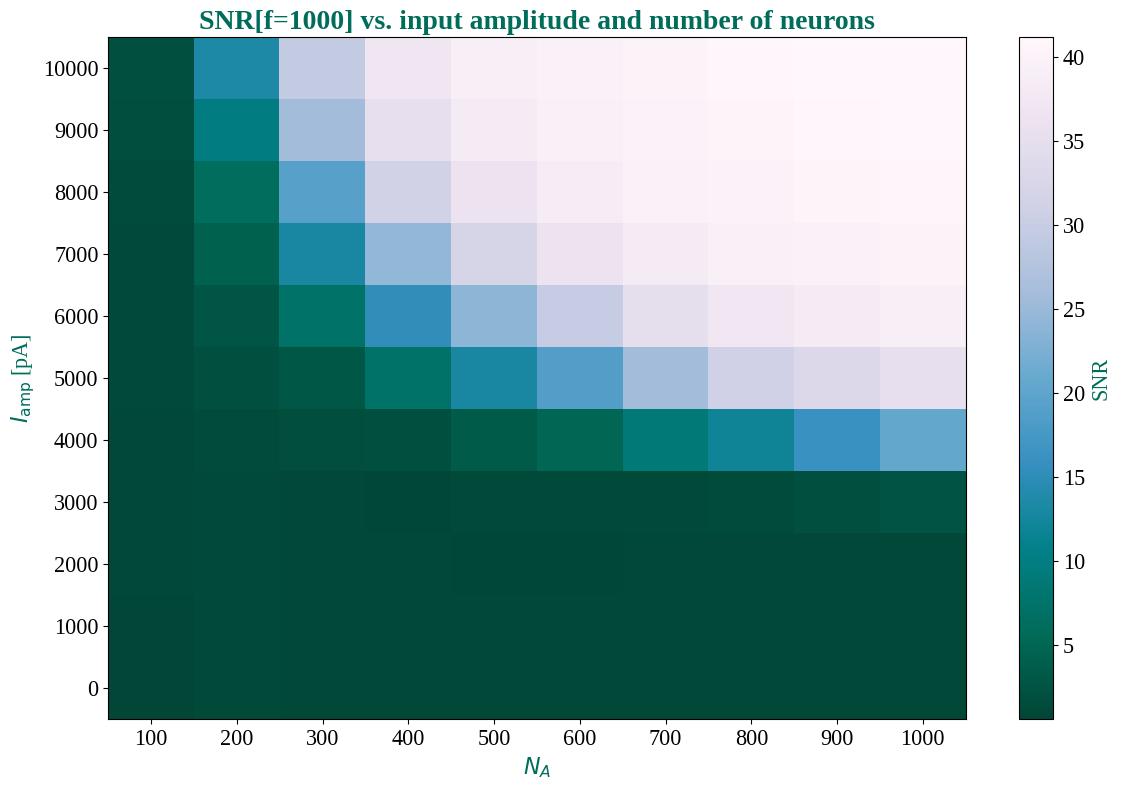

Time elapsed: 5318.457528591156


In [ ]:
snr_heatmap(a_values=np.linspace(0,10000,11), num_A_values=np.linspace(100,1000,10, dtype=int),
            sim_time=100e3, save_fig=True)

In [ ]:
import time

# eks N = 10, 2500
# w = 1 for 1000 så w = 1 * N/1000

def snr_NxW(NxW_values, window=5,  sim_time=100e3, save_fig=False, f=1000, a=1000):
    start = time.time()
    plt.rcParams["font.family"] = "DejaVu Serif"
    
    print(f"simulation time: {sim_time}")
    beat = 20
    resolution = 0.25
    bin_size = 0.25

    fig, ax = plt.subplots(2,1)

    N_values = np.linspace(1,2500,num=10, dtype=int)

    colors = ["#009879", "#4CAF50", "teal", "#8BC34A", "#CDDC39", "#FFEB3B"]
    
    x_labels = [f"{N_A:.0f}" for N_A in NxW_values]
    array_snr = np.zeros((len(NxW_values), len(N_values)))
    array_fr = np.zeros((len(NxW_values), len(N_values)))
    
    for i, NxW in enumerate(NxW_values):
        w_values = np.ones(len(N_values))*NxW / N_values
        
        for j, w in enumerate(w_values):
            print(f"j:{j} , w: {w}, N: {N_values[j]} ")
            results = build_network(sim_time=sim_time, num_A=N_values[j],
                                    noisy=True, second_sine=True, beat=beat,
                                    f1=f, a=a, SD=250, weight=w,
                                    resolution=resolution)
    
            spike_times = results["spike_times"]

            array_fr[i,j] = results["Spike_rate"]
            
            if len(spike_times) > 0:
                freqs, psd_values = psd_welch(spike_times, sim_time, bin_size=bin_size, segments=16)
                psd_values = np.abs(psd_values)
                if len(freqs) == 0 or len(psd_values) == 0:
                    print(f"[ADVARSEL] Tom PSD for a={a}, N={N_values[j]}")
                    array_snr[i, j] = 0
                    continue
                    
                arg_f_beat = np.argmin(np.abs(freqs - beat))
                signal = psd_values[arg_f_beat]
                noise_mask = (freqs >= freqs[arg_f_beat] - window) & (freqs <= freqs[arg_f_beat] + window)
                noise = np.mean(psd_values[noise_mask])
    
                snr = signal / noise if noise > 0 else 0
                array_snr[i, j] = snr
            else:
                array_snr[i, j] = 0
        print("spikerate:", spike_times/len(spike_times))
    
    # --- Plot heatmap ---
        ax[0].plot(N_values, array_snr[i][:], color=colors[i], label=rf"$N_A*w = {NxW}$")
        
        ax[1].plot(N_values, array_fr[i][:], color=colors[i], label=rf"$N_A*w = {NxW}$")

    plt.rcParams["font.family"] = "DejaVu Serif"
    axis = plt.gca() 
    plot_layout(axis)
    ax[0].set_title(rf"A. SNR vs $N_A$", fontweight='bold', color="#006D5B", fontsize=20)
    ax[1].set_title(rf"B. Firing rate vs $N_A$", fontweight='bold', color="#006D5B", fontsize=20)
    plt.xlabel(r"$N_A$", fontsize=16)
    ax[0].set_ylabel("SNR", fontsize=16)
    ax[1].set_ylabel("spikes/sec")
    plt.legend()
    plt.xlim(0,np.max(NxW_values))
    
    plot_layout(ax[0])
    plot_layout(ax[1])
    #ax.set_yscale("log")
    #ax.set_xscale("log")
        
    if save_fig:
        save_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(save_dir, exist_ok=True)
        file_index = 1
        while os.path.exists(os.path.join(save_dir, f"SNR_NA_{file_index}.png")):
            file_index += 1
        
        save_path = os.path.join(save_dir, f"SNR_NA_{file_index}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
        
        print(f"Saved plot as: {save_path}")
            
    plt.tight_layout()

    if save_fig:
        plt.savefig("snr_heatmap_1000.png", dpi=300)
    
    plt.show()
    end = time.time()
    print("Time elapsed:", end - start)
    



simulation time: 100000.0
j:0 , w: 500.0, N: 1 

Apr 24 09:10:38 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Apr 24 09:10:38 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
j:1 , w: 1.7985611510791366, N: 278 
j:2 , w: 0.8992805755395683, N: 556 
j:3 , w: 0.5995203836930456, N: 834 
j:4 , w: 0.45004500450045004, N: 1111 
j:5 , w: 0.3599712023038157, N: 1389 
j:6 , w: 0.29994001199760045, N: 1667 
j:7 , w: 0.257201646090535, N: 1944 
j:8 , w: 0.22502250225022502, N: 2222 
j:9 , w: 0.2, N: 2500 
spikerate: [  0.48852772   0.69359465   0.86376673   0.99808795   1.5540153
   2.5081262    2.91634799   3.25956023   3.40200765   3.7418738
   3.78250478   3.89483748   3.96510516   4.34655832   4.80449331
   4.98565966   5.10803059   5.89866157   6.13145315   6.18594646
   6.23661568   6.27342256   6.32648184   6.68785851   7.07600382
   7.57026769   8.43546845   9.93690249  10.02342256  10.0750478
  10.2

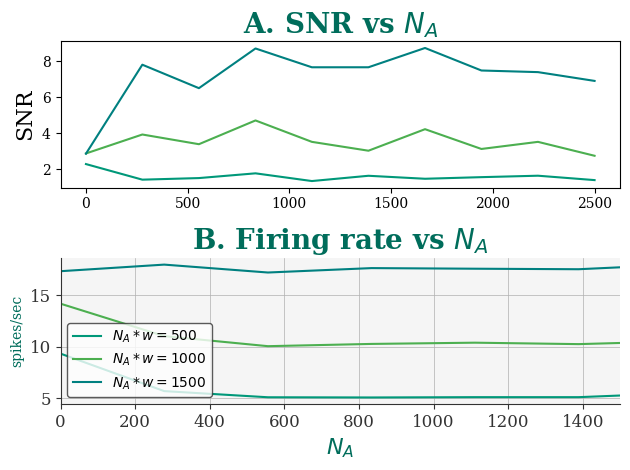

Time elapsed: 3008.7608029842377


In [6]:
snr_NxW(NxW_values=[500,1000,1500], window=5,  sim_time=100e3, save_fig=False, f=1000)